# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set the visual style for the plots for better aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# INITIAL DATA OVERVIEW

- Get a high-level summary of the dataset to understand its structure.

In [3]:
df = pd.read_csv('vaccinations_cleaned.csv')

In [4]:
print("\n--- Shape of the Dataset (Rows, Columns) ---")
print(df.shape)


--- Shape of the Dataset (Rows, Columns) ---
(196246, 16)


In [5]:
print("\n--- Summary Statistics for Numerical Columns ---")
# Displaying transpose (.T) for better readability
print(df.describe().T)


--- Summary Statistics for Numerical Columns ---
                                        count          mean           std  \
total_vaccinations                   196246.0  2.444817e+08  1.246838e+09   
people_vaccinated                    196246.0  1.028202e+08  5.291639e+08   
people_fully_vaccinated              196246.0  9.095591e+07  4.801717e+08   
total_boosters                       196246.0  4.112769e+07  2.375663e+08   
daily_vaccinations_raw               196246.0  2.675667e+05  1.946913e+06   
daily_vaccinations                   196246.0  2.821154e+05  1.916512e+06   
total_vaccinations_per_hundred       196246.0  5.409327e+01  8.335813e+01   
people_vaccinated_per_hundred        196246.0  2.211855e+01  3.241903e+01   
people_fully_vaccinated_per_hundred  196246.0  1.936357e+01  3.005289e+01   
total_boosters_per_hundred           196246.0  9.914902e+00  2.260578e+01   
daily_vaccinations_per_million       196246.0  1.839996e+03  3.111543e+03   
daily_people_vaccinated   

# UNIVARIATE ANALYSIS (ANALYZING SINGLE VARIABLES)

- In this section, we analyze individual variables to find patterns.

## Analyzing: Top 10 Countries by Total Vaccinations

In [6]:
# To get the most recent number, we first find the latest date for each country
latest_data = df.loc[df.groupby('location')['date'].idxmax()]

In [7]:
# Sort the countries by the total number of vaccinations in descending order
top_10_countries = latest_data.sort_values(by='total_vaccinations', ascending=False).head(10)

C:\Users\sawar\AppData\Local\Temp\ipykernel_14200\4096724331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_vaccinations', y='location', data=top_10_countries, palette='viridis')


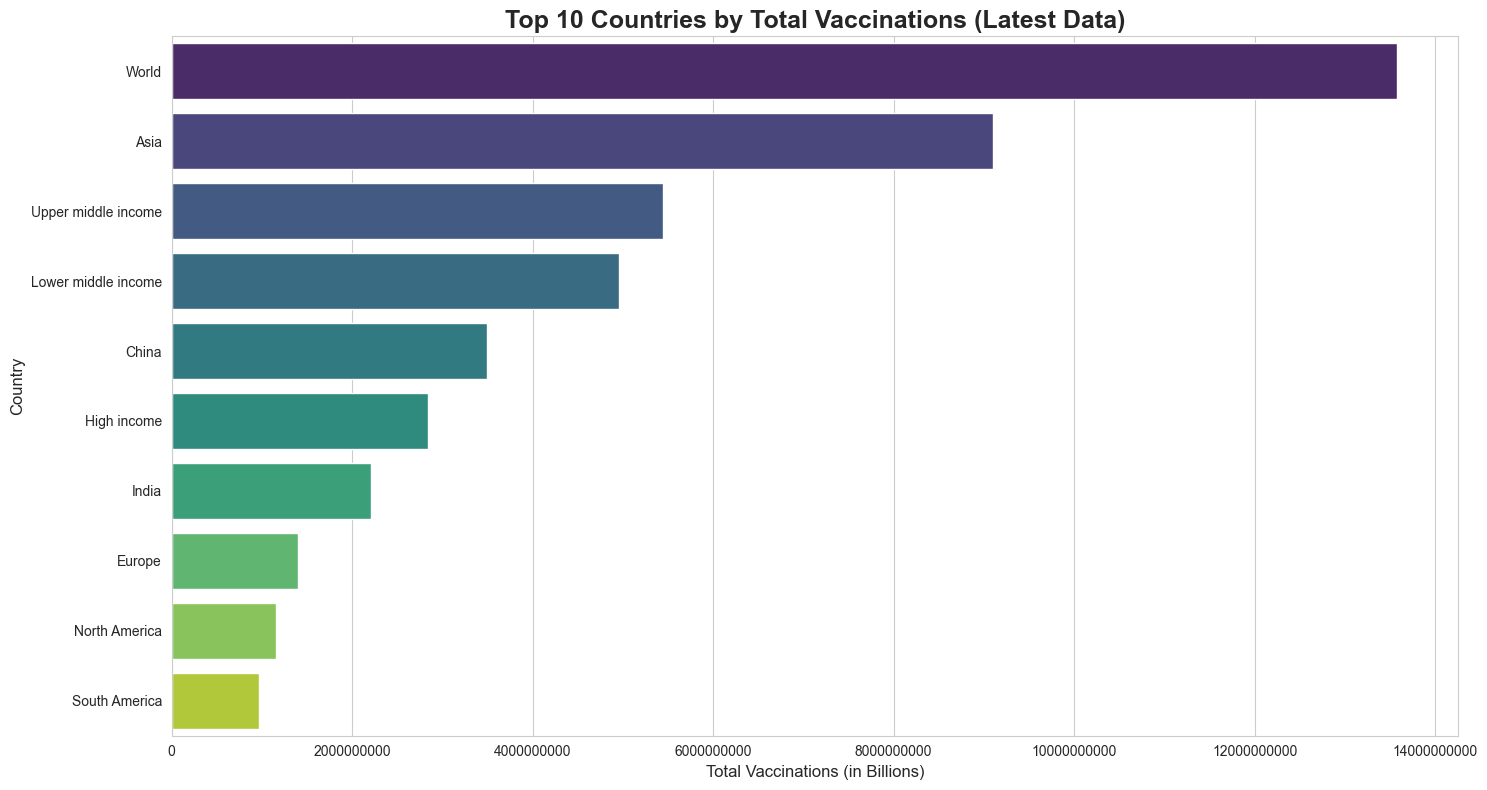

In [8]:
plt.figure(figsize=(15, 8))
sns.barplot(x='total_vaccinations', y='location', data=top_10_countries, palette='viridis')
plt.title('Top 10 Countries by Total Vaccinations (Latest Data)', fontsize=18, weight='bold')
plt.xlabel('Total Vaccinations (in Billions)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Prevents scientific notation
plt.tight_layout()
plt.show()

- Conclusion: A few countries, notably China and India, are responsible for a significant portion of the total global vaccinations.

## Analyzing: Global Daily Vaccination Trend

In [9]:
# Group data by date and sum the 'daily_vaccinations' to get the global daily total
global_daily_vaccinations = df.groupby('date')['daily_vaccinations'].sum().reset_index()

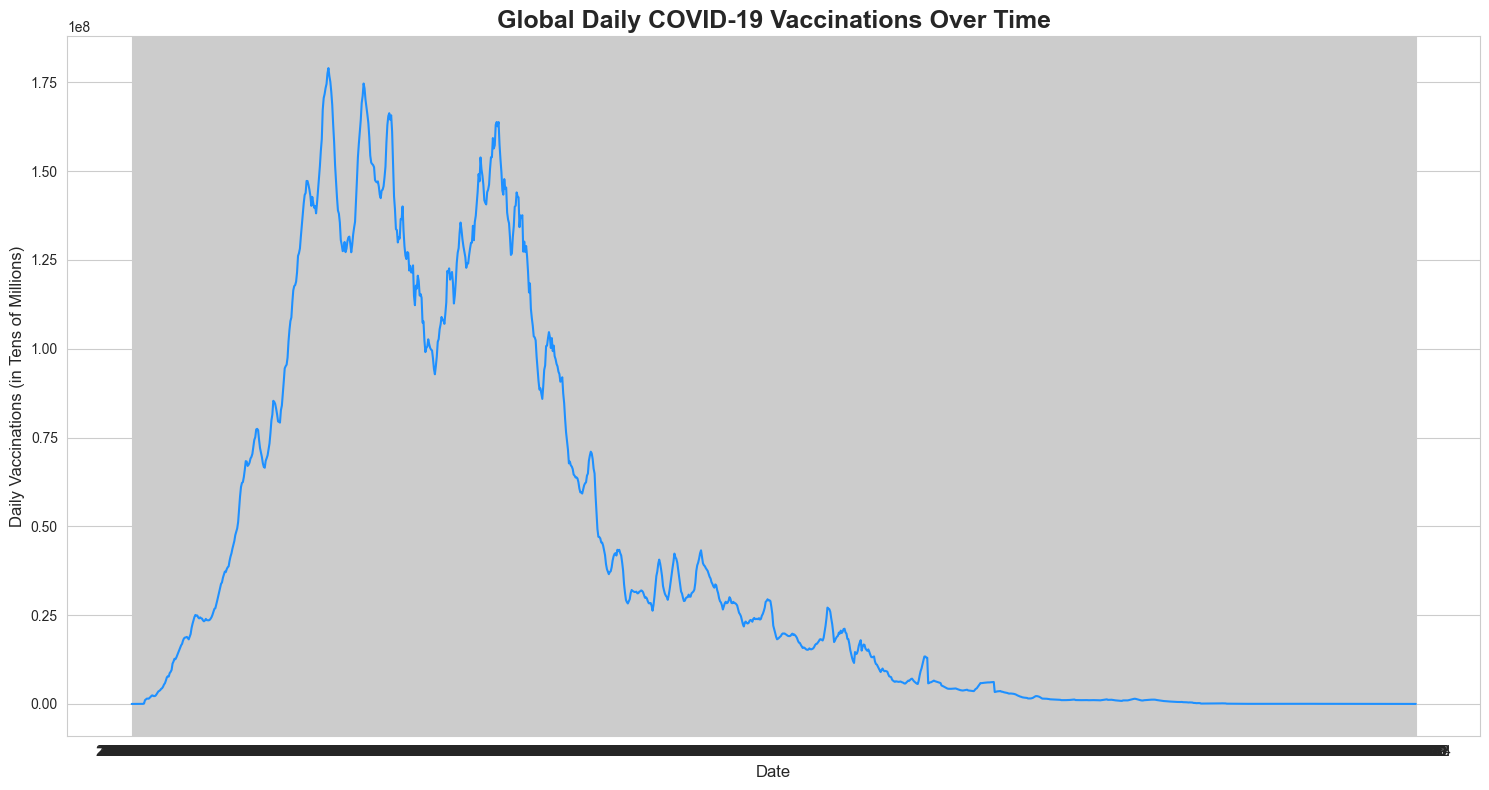

In [10]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='date', y='daily_vaccinations', data=global_daily_vaccinations, color='dodgerblue')
plt.title('Global Daily COVID-19 Vaccinations Over Time', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Vaccinations (in Tens of Millions)', fontsize=12)
plt.tight_layout()
plt.show()

- Conclusion: The global daily vaccination trend shows several peaks and troughs, which could correspond to vaccine availability, new waves of the pandemic, or policy changes across the world.

# BIVARIATE ANALYSIS (ANALYZING RELATIONSHIPS BETWEEN TWO VARIABLES)

- Here, we explore the relationships between pairs of variables.

## Analyzing: People Vaccinated vs. People Fully Vaccinated

In [11]:
# We use a sample of the data to prevent the plot from becoming too crowded (overplotting)
# We also filter out rows with no vaccinations to make the plot cleaner
df_sample = df[df['people_vaccinated'] > 0].sample(n=2500, random_state=1)

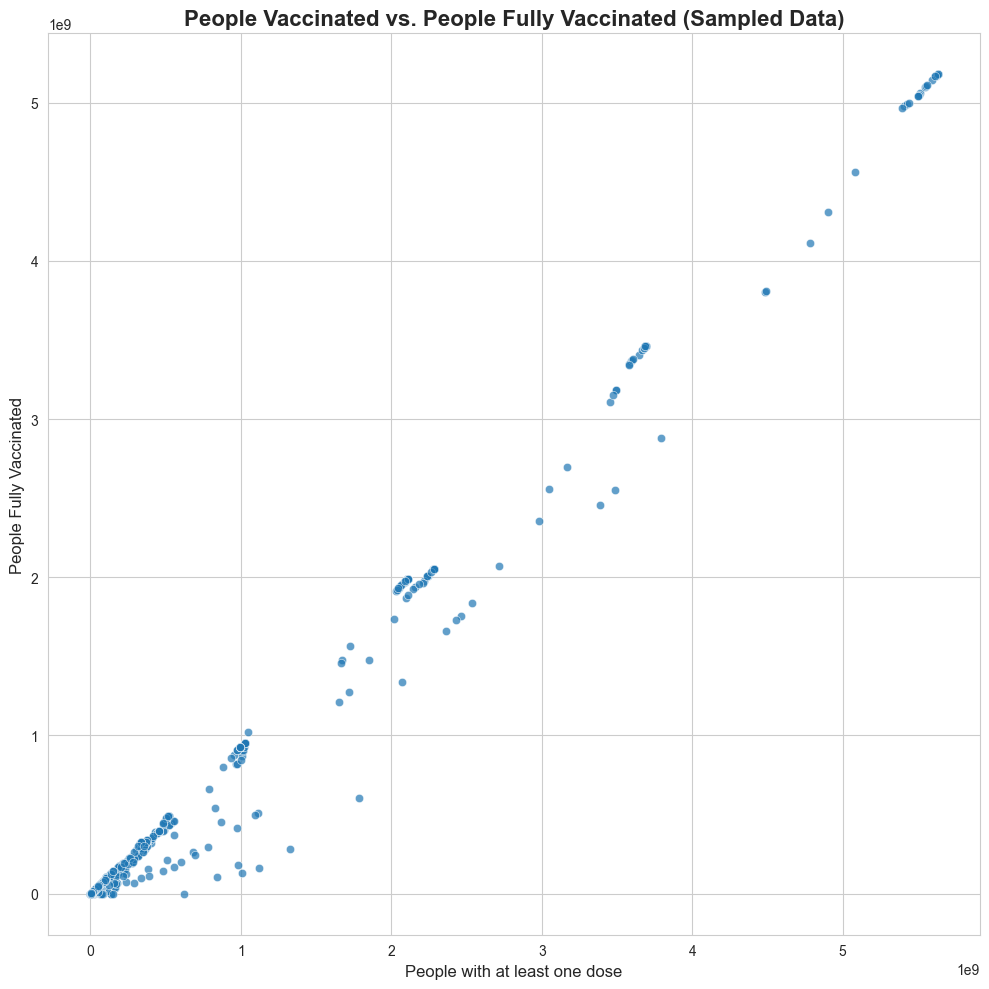

In [12]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x='people_vaccinated', y='people_fully_vaccinated', data=df_sample, alpha=0.7)
plt.title('People Vaccinated vs. People Fully Vaccinated (Sampled Data)', fontsize=16, weight='bold')
plt.xlabel('People with at least one dose', fontsize=12)
plt.ylabel('People Fully Vaccinated', fontsize=12)
plt.tight_layout()
plt.show()

- Conclusion: There is a very strong, positive, and linear relationship between people with at least one dose and those fully vaccinated, which is expected. This confirms the consistency of the data.

## Analyzing: Vaccination Progress for Selected Countries (per 100 people)

In [13]:
# List of countries to compare
countries_to_compare = ['United States', 'India', 'Brazil', 'United Kingdom', 'Germany', 'Japan']
df_countries = df[df['location'].isin(countries_to_compare)]

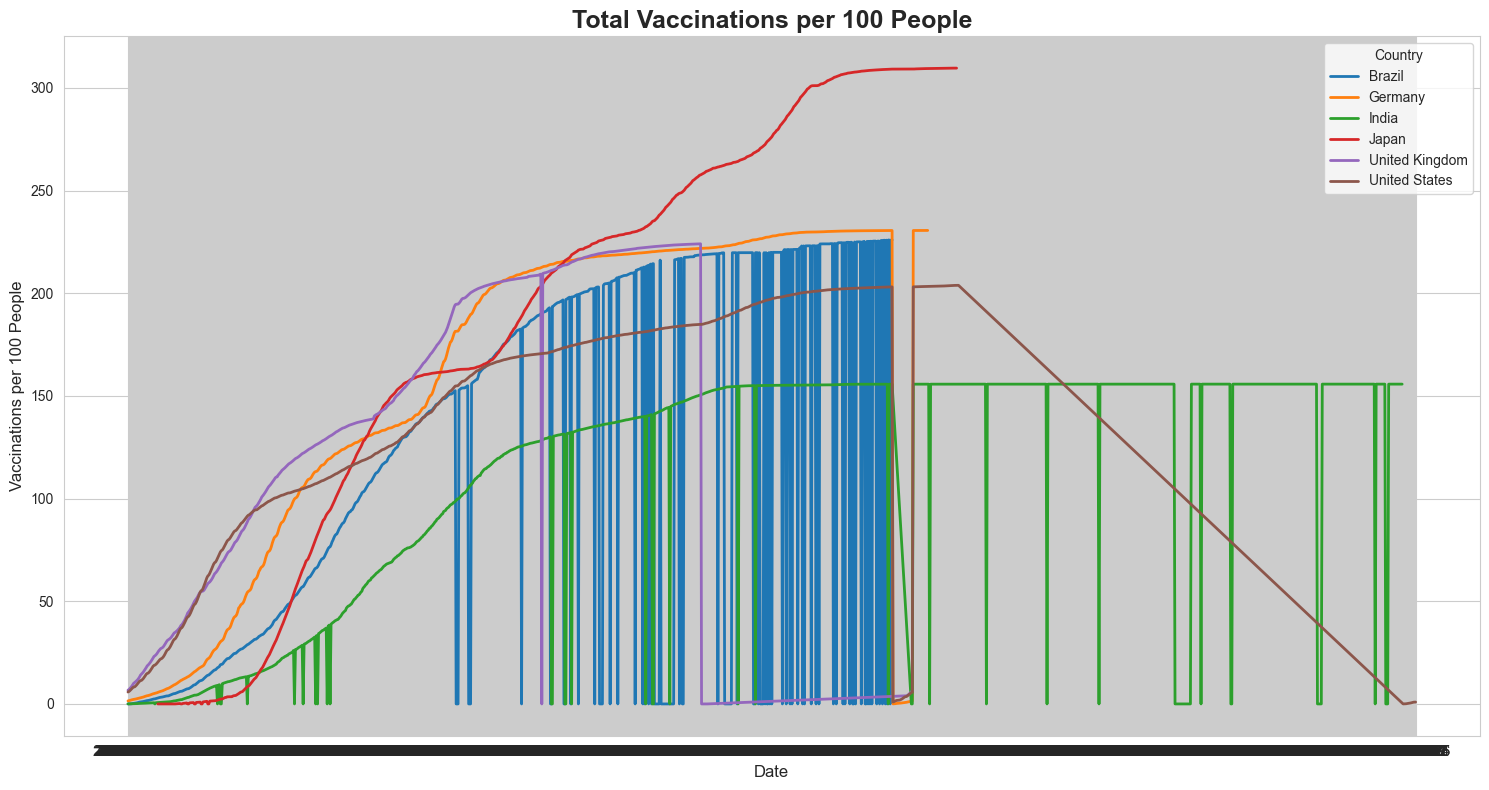

In [14]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='date', y='total_vaccinations_per_hundred', hue='location', data=df_countries, lw=2)
plt.title('Total Vaccinations per 100 People', fontsize=18, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Vaccinations per 100 People', fontsize=12)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

- Conclusion: Comparing vaccinations per capita (per 100 people) reveals different rollout strategies and speeds. Some countries had a faster initial rollout, while others have caught up or surpassed them over time.

# ATTRIBUTE CORRELATION ANALYSIS

- We create a heatmap to visualize the correlation between all numerical variables.

In [16]:
# Select only the columns with numerical data for the correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

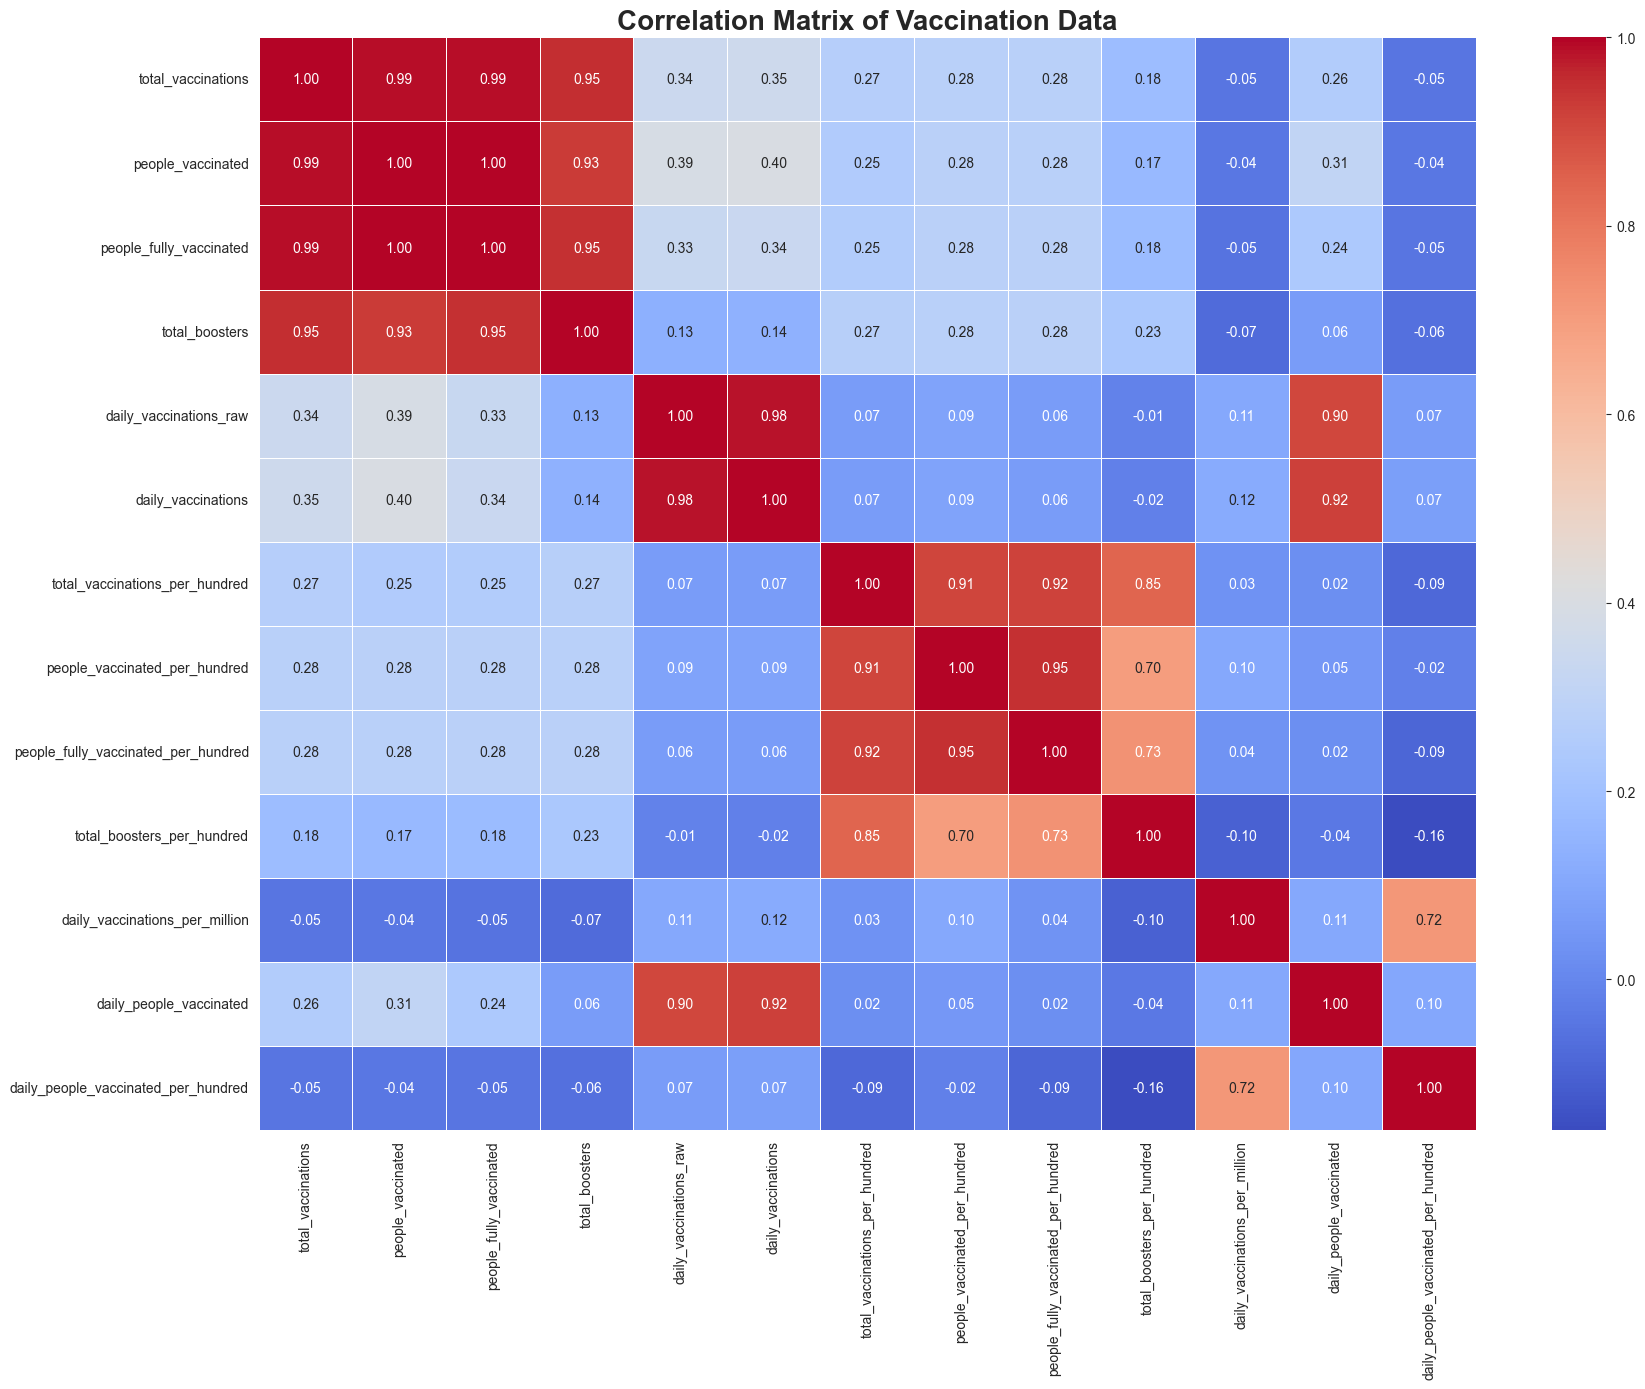

In [17]:
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Vaccination Data', fontsize=20, weight='bold')
plt.tight_layout()
plt.show()

- Conclusion: The heatmap shows extremely strong positive correlations (close to +1.0) between all primary vaccination metrics (total, people vaccinated, fully vaccinated, boosters). This is a strong indicator of data integrity. Metrics like 'daily_vaccinations' are also highly correlated with the totals, which logically follows.